# Final Assignment Analysis - Company A Telecom Churn

This notebook supports the business proposal slides. The goal is to understand customer churn in Company A's telecom dataset and build a practical machine learning model that can prioritize retention actions.

**Business question:** Which customers are likely to churn in the next 31-60 days, and how should Company A act on this prediction?

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.metrics import roc_auc_score, average_precision_score
from xgboost import XGBClassifier

pd.set_option('display.max_columns', 120)
RANDOM_STATE = 55
DATA_DIR = Path('.')
if not (DATA_DIR / 'Client.csv').exists():
    DATA_DIR = Path('/mnt/data')


## 1. Load and join the data

The dataset contains two tables: customer profile information (`Client.csv`) and service usage / churn information (`Record.csv`). I join them using `Customer_ID`.

In [2]:
client = pd.read_csv(DATA_DIR / 'Client.csv')
record = pd.read_csv(DATA_DIR / 'Record.csv')

df = record.merge(client, on='Customer_ID', how='left')
print('Client shape:', client.shape)
print('Record shape:', record.shape)
print('Joined shape:', df.shape)
print('Churn rate:', round(df['churn'].mean(), 4))
df.head()

Client shape: (100000, 50)
Record shape: (100000, 51)
Joined shape: (100000, 100)
Churn rate: 0.4956


,rev_Mean,mou_Mean,totmrc_Mean,da_Mean,ovrmou_Mean,ovrrev_Mean,vceovr_Mean,datovr_Mean,roam_Mean,change_mou,change_rev,drop_vce_Mean,drop_dat_Mean,blck_vce_Mean,blck_dat_Mean,unan_vce_Mean,unan_dat_Mean,plcd_vce_Mean,plcd_dat_Mean,recv_vce_Mean,recv_sms_Mean,comp_vce_Mean,comp_dat_Mean,custcare_Mean,ccrndmou_Mean,cc_mou_Mean,inonemin_Mean,threeway_Mean,mou_cvce_Mean,mou_cdat_Mean,mou_rvce_Mean,owylis_vce_Mean,mouowylisv_Mean,iwylis_vce_Mean,mouiwylisv_Mean,peak_vce_Mean,peak_dat_Mean,mou_peav_Mean,mou_pead_Mean,opk_vce_Mean,opk_dat_Mean,mou_opkv_Mean,mou_opkd_Mean,drop_blk_Mean,attempt_Mean,complete_Mean,callfwdv_Mean,callwait_Mean,churn,months,Customer_ID,uniqsubs,actvsubs,new_cell,crclscod,asl_flag,totcalls,totmou,totrev,adjrev,adjmou,adjqty,avgrev,avgmou,avgqty,avg3mou,avg3qty,avg3rev,avg6mou,avg6qty,avg6rev,prizm_social_one,area,dualband,refurb_new,hnd_price,phones,models,hnd_webcap,truck,rv,ownrent,lor,dwlltype,marital,adults,infobase,income,numbcars,HHstatin,dwllsize,forgntvl,ethnic,kid0_2,kid3_5,kid6_10,kid11_15,kid16_17,creditcd,eqpdays
0,23.9975,219.25,22.500,0.2475,0.00,0.0,0.0,0.0,0.0,-157.25,-18.9975,0.666667,0.0,0.666667,0.0,6.333333,0.0,52.333333,0.0,42.333333,0.0,45.000000,0.0,0.000000,0.000000,0.000000,18.000000,0.000000,90.643333,0.0,97.176667,0.000000,0.000000,0.000000,0.000000,58.000000,0.0,132.600000,0.0,24.000000,0.0,55.220000,0.0,1.333333,52.333333,45.000000,0.0,0.333333,1,61,1000001,2,1,U,A,N,1652,4228.00000,1504.62,1453.44,4085.00,1602,29.66,83.37,32.69,272,116,30,322.0,136.0,38.0,S,NORTHWEST/ROCKY MOUNTAIN AREA,Y,N,149.98999,2.0,2.0,WCMB,0.0,0.0,O,15.0,S,S,1.0,M,4.0,3.0,C,A,0.0,N,U,U,U,U,U,Y,361.0
1,57.4925,482.75,37.425,0.2475,22.75,9.1,9.1,0.0,0.0,532.25,50.9875,8.333333,0.0,1.000000,0.0,61.333333,0.0,263.333333,0.0,69.000000,0.0,193.333333,0.0,1.666667,6.333333,5.463333,53.000000,0.333333,189.396667,0.0,55.280000,46.333333,24.216667,6.333333,3.696667,83.666667,0.0,75.333333,0.0,157.000000,0.0,169.343333,0.0,9.333333,263.333333,193.333333,0.0,5.666667,0,56,1000002,1,1,N,EA,N,14654,26400.00000,2851.68,2833.88,26367.00,14624,51.53,479.40,265.89,305,158,40,477.0,275.0,48.0,U,CHICAGO AREA,N,N,NaN,7.0,6.0,WC,1.0,1.0,NaN,1.0,S,S,1.0,M,5.0,1.0,C,A,0.0,Z,U,U,U,U,U,Y,240.0
2,16.9900,10.25,16.990,0.0000,0.00,0.0,0.0,0.0,0.0,-4.25,0.0000,0.333333,0.0,0.000000,0.0,2.666667,0.0,9.000000,0.0,0.333333,0.0,6.000000,0.0,0.000000,0.000000,0.000000,0.333333,0.000000,5.426667,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,0.0,5.193333,0.0,1.000000,0.0,0.233333,0.0,0.333333,9.000000,6.000000,0.0,0.000000,1,58,1000003,1,1,Y,C,N,7903,24385.05333,2155.91,1934.47,24303.05,7888,34.54,433.98,140.86,12,7,17,11.0,6.0,17.0,S,GREAT LAKES AREA,N,N,29.98999,2.0,1.0,NaN,0.0,0.0,O,7.0,S,M,2.0,M,5.0,2.0,C,A,0.0,N,U,Y,U,U,U,Y,1504.0
3,38.0000,7.50,38.000,0.0000,0.00,0.0,0.0,0.0,0.0,-1.50,0.0000,0.000000,0.0,0.000000,0.0,0.000000,0.0,3.666667,0.0,1.333333,0.0,3.666667,0.0,0.000000,0.000000,0.000000,1.333333,0.000000,8.410000,0.0,0.413333,0.333333,0.256667,0.000000,0.000000,1.333333,0.0,3.380000,0.0,3.666667,0.0,5.450000,0.0,0.000000,3.666667,3.666667,0.0,0.000000,0,60,1000004,1,1,Y,B,N,1502,3065.00000,2000.90,1941.81,3035.00,1479,40.45,63.23,30.81,8,3,38,50.0,25.0,40.0,T,CHICAGO AREA,N,N,29.98999,1.0,1.0,NaN,0.0,0.0,NaN,6.0,M,M,4.0,M,6.0,1.0,C,D,0.0,U,Y,U,U,U,U,Y,1812.0
4,55.2300,570.50,71.980,0.0000,0.00,0.0,0.0,0.0,0.0,38.50,0.0000,9.666667,0.0,0.666667,0.0,77.000000,0.0,222.333333,0.0,94.666667,0.0,137.000000,0.0,8.666667,15.000000,11.076667,66.000000,0.000000,285.233333,0.0,106.330000,14.666667,10.816667,0.666667,0.366667,97.333333,0.0,173.476667,0.0,90.333333,0.0,218.086667,0.0,10.333333,222.333333,137.000000,0.0,0.000000,0,57,1000005,1,1,Y,A,N,4485,14028.00000,2181.12,2166.48,13965.00,4452,38.69,249.38,79.50,558,191,55,586.0,196.0,80.0,U,NEW ENGLAND AREA,Y,N,149.98999,6.0,4.0,WCMB,0.0,0.0,R,5.0,M,S,1.0,M,6.0,1.0,C,O,0.0,I,U,U,U,U,U,Y,434.0


## 2. Basic EDA

The target variable is `churn`, defined as churn between 31-60 days after the observation date. First I check the overall churn rate and a few business-relevant behavioral signals.

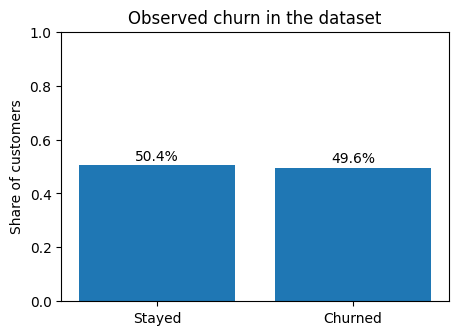

In [3]:
fig, ax = plt.subplots(figsize=(5, 3.5))
vals = [1 - df['churn'].mean(), df['churn'].mean()]
ax.bar(['Stayed', 'Churned'], vals)
ax.set_ylim(0, 1)
ax.set_ylabel('Share of customers')
ax.set_title('Observed churn in the dataset')
for i, v in enumerate(vals):
    ax.text(i, v + 0.02, f'{v:.1%}', ha='center')
plt.show()

In [4]:
def make_group_table(data, group_col, target='churn'):
    return (data.groupby(group_col)
            .agg(customers=(target, 'size'), churn_rate=(target, 'mean'), avg_monthly_revenue=('rev_Mean', 'mean'))
            .reset_index())

# Usage decline groups
usage_bins = [-np.inf, -100, -25, 25, 100, np.inf]
usage_labels = ['large decline', 'moderate decline', 'stable', 'moderate growth', 'large growth']
df['usage_change_group'] = pd.cut(df['change_mou'], bins=usage_bins, labels=usage_labels)
usage_change_tbl = make_group_table(df, 'usage_change_group')
usage_change_tbl

/tmp/ipykernel_5529/2043873975.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  return (data.groupby(group_col)


,usage_change_group,customers,churn_rate,avg_monthly_revenue
0,large decline,22623,0.536224,75.906539
1,moderate decline,18438,0.492299,49.067326
2,stable,24206,0.497934,39.609583
3,moderate growth,14800,0.455135,51.005028
4,large growth,19042,0.466705,78.275420


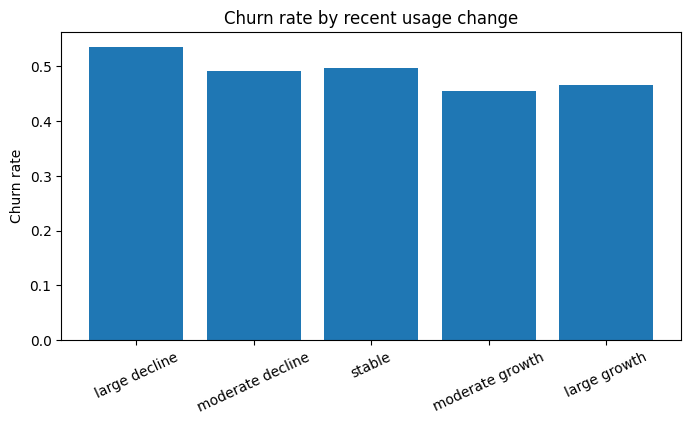

In [5]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(usage_change_tbl['usage_change_group'].astype(str), usage_change_tbl['churn_rate'])
ax.set_ylabel('Churn rate')
ax.set_title('Churn rate by recent usage change')
ax.tick_params(axis='x', rotation=25)
plt.show()

### Interpretation from EDA

A key pattern is that churn is not only a demographic problem. It is connected with service usage, device/equipment status, customer care interaction, and recent changes in behavior. This supports a retention system that monitors customers continuously instead of using a one-time manual rule.

## 3. Feature engineering

I created simple business features that can be explained to the client, such as call completion rate, dropped/blocked call rate, customer-care intensity, recent usage ratios, and equipment age.

In [6]:
def safe_div(num, den):
    return np.where((den.notna()) & (den > 0), num / den, 0)

feature_df = df.copy()
feature_df['drop_block_rate'] = safe_div(feature_df['drop_blk_Mean'], feature_df['attempt_Mean'])
feature_df['complete_rate'] = safe_div(feature_df['complete_Mean'], feature_df['attempt_Mean'])
feature_df['care_per_attempt'] = safe_div(feature_df['custcare_Mean'], feature_df['attempt_Mean'])
feature_df['revenue_per_minute'] = safe_div(feature_df['rev_Mean'], feature_df['mou_Mean'])
feature_df['overage_revenue_share'] = safe_div(feature_df['ovrrev_Mean'], feature_df['rev_Mean'])
feature_df['recent_mou_ratio_3_to_6'] = safe_div(feature_df['avg3mou'], feature_df['avg6mou'])
feature_df['recent_rev_ratio_3_to_6'] = safe_div(feature_df['avg3rev'], feature_df['avg6rev'])
feature_df['equipment_age_months'] = feature_df['eqpdays'] / 30.0
feature_df['household_active_ratio'] = safe_div(feature_df['actvsubs'], feature_df['uniqsubs'])
feature_df['avg_rev_gap_3m_to_lifetime'] = feature_df['avg3rev'] - feature_df['avgrev']
feature_df['avg_mou_gap_3m_to_lifetime'] = feature_df['avg3mou'] - feature_df['avgmou']

model_features = [
    'rev_Mean','mou_Mean','totmrc_Mean','ovrmou_Mean','ovrrev_Mean',
    'change_mou','change_rev','drop_vce_Mean','blck_vce_Mean','unan_vce_Mean',
    'custcare_Mean','drop_blk_Mean','attempt_Mean','complete_Mean','months',
    'totcalls','totmou','totrev','avgrev','avgmou','avg3mou','avg3rev','avg6mou','avg6rev',
    'hnd_price','phones','eqpdays','drop_block_rate','complete_rate','care_per_attempt',
    'overage_revenue_share','recent_mou_ratio_3_to_6','recent_rev_ratio_3_to_6',
    'equipment_age_months','household_active_ratio','avg_rev_gap_3m_to_lifetime','avg_mou_gap_3m_to_lifetime'
]

X = feature_df[model_features].replace([np.inf, -np.inf], np.nan)
y = feature_df['churn'].astype(int)

imputer = SimpleImputer(strategy='median')
X_imp = imputer.fit_transform(X)
X.shape

(100000, 37)

## 4. Machine learning model

I used **XGBoost Gradient-Boosted Decision Trees** because it can capture non-linear patterns and feature interactions in tabular data. The evaluation metric is **ROC-AUC**, which is suitable because the business goal is to rank customers by churn risk and prioritize actions.

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X_imp, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

model = XGBClassifier(
    n_estimators=80,
    max_depth=3,
    learning_rate=0.06,
    subsample=0.85,
    colsample_bytree=0.85,
    reg_lambda=2,
    random_state=RANDOM_STATE,
    n_jobs=2,
    eval_metric='auc',
    tree_method='hist'
)

model.fit(X_train, y_train, verbose=False)
proba_test = model.predict_proba(X_test)[:, 1]
auc = roc_auc_score(y_test, proba_test)
ap = average_precision_score(y_test, proba_test)
print(f'Model: XGBoost Gradient-Boosted Decision Trees')
print(f'Evaluation metric: ROC-AUC on stratified 20% holdout test set')
print(f'ROC-AUC: {auc:.3f}')
print(f'Average precision: {ap:.3f}')

Model: XGBoost Gradient-Boosted Decision Trees
Evaluation metric: ROC-AUC on stratified 20% holdout test set
ROC-AUC: 0.667
Average precision: 0.651


## 5. Risk ranking and model insight

The model is not used as a black box decision to cancel customers. It is used as a priority score so that Company A can contact the highest-risk customers first.

In [8]:
feature_df['churn_probability'] = model.predict_proba(X_imp)[:, 1]
feature_df['risk_decile'] = pd.qcut(feature_df['churn_probability'], 10, labels=list(range(1, 11)), duplicates='drop')

risk_decile_table = (feature_df.groupby('risk_decile')
    .agg(customers=('churn', 'size'),
         actual_churn_rate=('churn', 'mean'),
         avg_monthly_revenue=('rev_Mean', 'mean'),
         total_monthly_revenue=('rev_Mean', 'sum'),
         avg_change_mou=('change_mou', 'mean'))
    .reset_index())
risk_decile_table

/tmp/ipykernel_5529/3415638420.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  risk_decile_table = (feature_df.groupby('risk_decile')


,risk_decile,customers,actual_churn_rate,avg_monthly_revenue,total_monthly_revenue,avg_change_mou
0,1,10000,0.2147,55.785169,557293.841667,47.018821
1,2,10000,0.3208,71.449678,711996.045000,21.393948
2,3,10000,0.4056,69.363525,691415.615000,-19.629711
3,4,10000,0.4464,57.530856,572719.674167,-2.737831
4,5,10000,0.4939,57.184518,568642.844167,2.763533
5,6,10000,0.5168,54.907208,547644.490000,1.379071
6,7,10000,0.5606,56.298998,560963.217500,-6.465379
7,8,10000,0.6021,58.069329,579241.557500,-32.783823
8,9,10000,0.6388,58.171365,579910.336667,-52.396050
9,10,10000,0.7565,48.416121,481207.828333,-99.698889


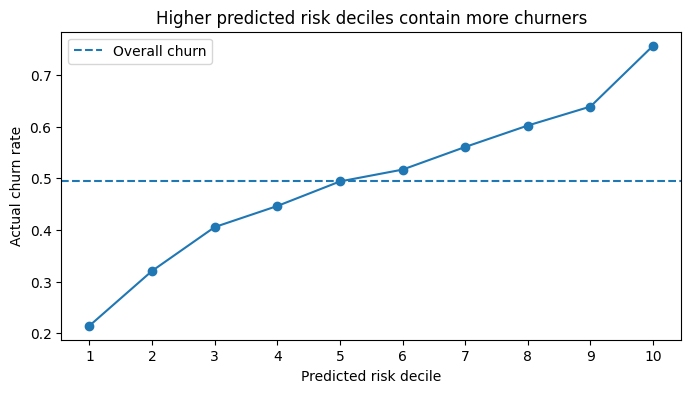

In [9]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(risk_decile_table['risk_decile'].astype(str), risk_decile_table['actual_churn_rate'], marker='o')
ax.axhline(feature_df['churn'].mean(), linestyle='--', label='Overall churn')
ax.set_ylabel('Actual churn rate')
ax.set_xlabel('Predicted risk decile')
ax.set_title('Higher predicted risk deciles contain more churners')
ax.legend()
plt.show()

In [10]:
importance = pd.DataFrame({
    'feature': model_features,
    'importance': model.feature_importances_
}).sort_values('importance', ascending=False)
importance.head(15)

,feature,importance
33,equipment_age_months,0.246461
26,eqpdays,0.125353
25,phones,0.066444
14,months,0.045892
36,avg_mou_gap_3m_to_lifetime,0.037134
24,hnd_price,0.036235
13,complete_Mean,0.029667
34,household_active_ratio,0.029586
3,ovrmou_Mean,0.027859
31,recent_mou_ratio_3_to_6,0.026749


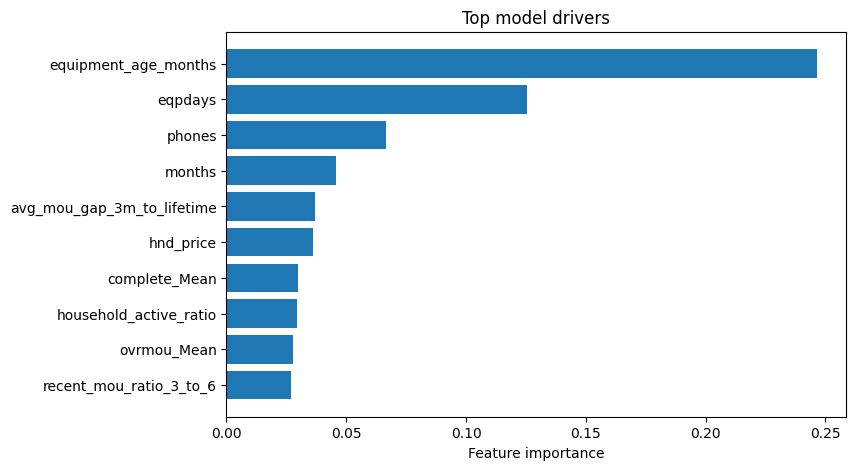

In [11]:
fig, ax = plt.subplots(figsize=(8, 5))
top_imp = importance.head(10).sort_values('importance')
ax.barh(top_imp['feature'], top_imp['importance'])
ax.set_xlabel('Feature importance')
ax.set_title('Top model drivers')
plt.show()

## 6. Business impact calculation

I calculate the revenue at risk using Company A's monthly revenue variable (`rev_Mean`). Because the original currency is not disclosed, I report the numbers as **billing units**. For the proposal, I use a conservative pilot assumption: analytics-driven retention reduces churn among the targeted group by 15%.

In [12]:
overall_churn = feature_df['churn'].mean()
prob_q80 = feature_df['churn_probability'].quantile(0.80)
rev_q75 = feature_df['rev_Mean'].quantile(0.75)

top20 = feature_df[feature_df['churn_probability'] >= prob_q80]
high_value_top20 = feature_df[(feature_df['churn_probability'] >= prob_q80) & (feature_df['rev_Mean'] >= rev_q75)]

def impact_summary(segment, name):
    annual_revenue_at_risk = segment['rev_Mean'].sum() * 12
    potential_preserved = annual_revenue_at_risk * 0.15
    return {
        'segment': name,
        'customers': len(segment),
        'actual_churn_rate': segment['churn'].mean(),
        'annual_revenue_at_risk_billing_units': annual_revenue_at_risk,
        'potential_preserved_if_churn_reduced_15pct': potential_preserved
    }

impact_table = pd.DataFrame([
    impact_summary(top20, 'Top 20% predicted risk'),
    impact_summary(high_value_top20, 'High-value customers in top 20% risk')
])
impact_table

,segment,customers,actual_churn_rate,annual_revenue_at_risk_billing_units,potential_preserved_if_churn_reduced_15pct
0,Top 20% predicted risk,20000,0.697650,1.273342e+07,1910012.697
1,High-value customers in top 20% risk,4225,0.669822,5.601650e+06,840247.521


## 7. Proposed solution

**Proposal:** Build a Churn Early-Warning & Retention System for Company A.

The model should score customers monthly and place them into practical action groups:

1. **High-value at-risk customers:** proactive retention call and loyalty offer.
2. **Usage-decline risk:** engagement campaign and plan review.
3. **Service-quality risk:** network/service follow-up when dropped or blocked calls are high.
4. **Equipment-age risk:** device upgrade or contract renewal offer.

This approach avoids giving discounts to everyone. It targets the customers where revenue risk and churn probability overlap.

In [13]:
# Save key analysis outputs for slide preparation
risk_decile_table.to_csv('risk_decile_table.csv', index=False)
importance.to_csv('feature_importance_full.csv', index=False)
impact_table.to_csv('impact_table.csv', index=False)
print('Saved analysis tables.')

Saved analysis tables.


## 8. Conclusion

The model does not need to perfectly predict every customer to be valuable. It needs to rank customers well enough to focus retention actions. In this PoC, the top risk decile has a much higher actual churn rate than the overall base, which supports a targeted retention strategy for Company A.